# **Import Libraries**

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# **Load Dataset**

In [67]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

Saving Unemployment_Rate_upto_11_2020.csv to Unemployment_Rate_upto_11_2020 (1).csv


In [68]:
df = pd.read_csv("/content/Unemployment_Rate_upto_11_2020.csv")

In [76]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


/tmp/ipykernel_4735/1621362670.py:9: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


# **Explore Dataset**
**Shape**

In [77]:
df.shape

(267, 9)

# **Information**

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   267 non-null    object        
 1   Date                                     267 non-null    datetime64[ns]
 2   Frequency                                267 non-null    object        
 3   Estimated Unemployment Rate (%)          267 non-null    float64       
 4   Estimated Employed                       267 non-null    int64         
 5   Estimated Labour Participation Rate (%)  267 non-null    float64       
 6   Region.1                                 267 non-null    object        
 7   longitude                                267 non-null    float64       
 8   latitude                                 267 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1), 

# **Statistics**

In [79]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


# **Check Missing Values**

In [80]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Region.1,0
longitude,0
latitude,0


In [81]:
df.dropna(inplace=True)

In [83]:
df['Date'] = pd.to_datetime(df['Date'])

In [84]:
df['Month'] = df['Date'].dt.month_name()

df['Year'] = df['Date'].dt.year

In [85]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude,Month,Year
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74,January,2020
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74,February,2020
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74,March,2020
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74,April,2020
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74,May,2020


In [86]:
df['Region'].nunique()

27

In [87]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal'], dtype=object)

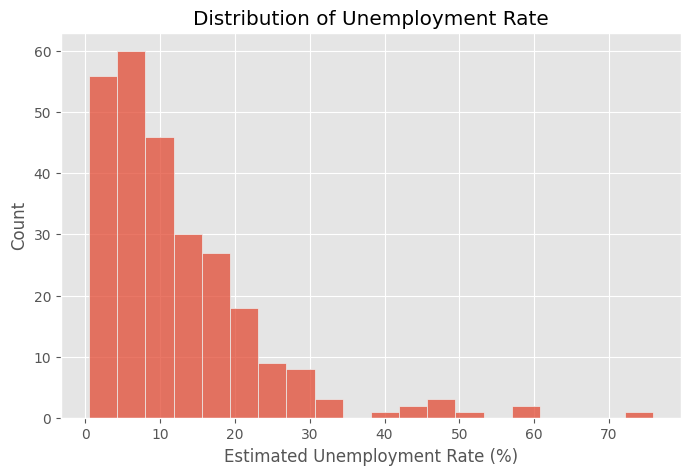

In [88]:
plt.figure(figsize=(8,5))

sns.histplot(df['Estimated Unemployment Rate (%)'], bins=20)

plt.title("Distribution of Unemployment Rate")

plt.show()

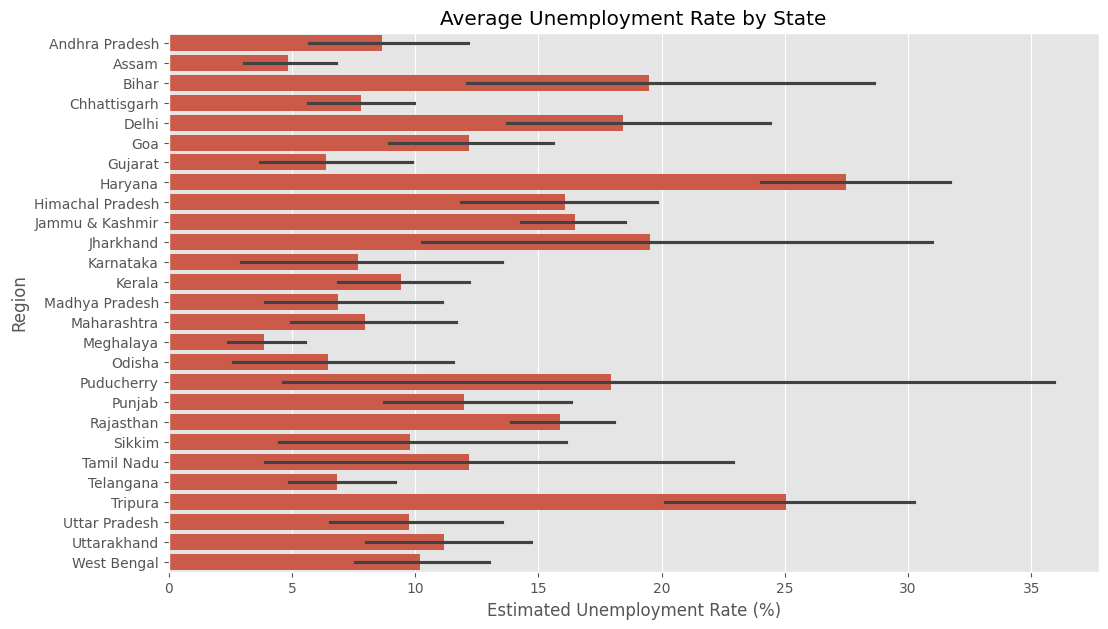

In [89]:
plt.figure(figsize=(12,7))

sns.barplot(
    x='Estimated Unemployment Rate (%)',
    y='Region',
    data=df
)

plt.title("Average Unemployment Rate by State")

plt.show()

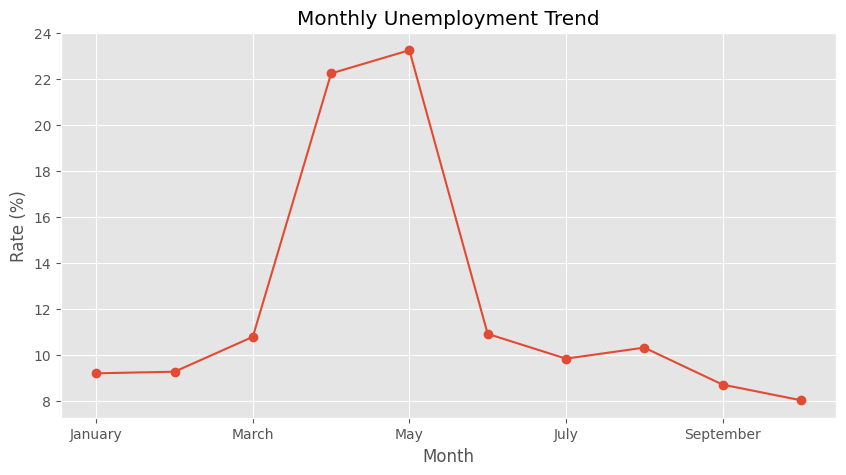

In [90]:
monthly = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()

monthly = monthly.reindex([
'January','February','March','April','May','June',
'July','August','September','October','November','December'
])

monthly.plot(kind='line', marker='o', figsize=(10,5))

plt.title("Monthly Unemployment Trend")

plt.ylabel("Rate (%)")

plt.show()

In [91]:
df['Covid'] = df['Date'].apply(
    lambda x: 'Before Covid' if x < pd.Timestamp('2020-03-01')
    else 'During Covid'
)

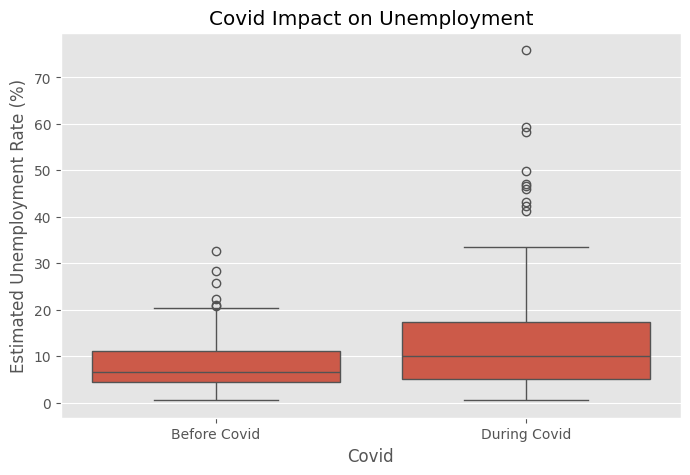

In [92]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Covid',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Covid Impact on Unemployment")

plt.show()

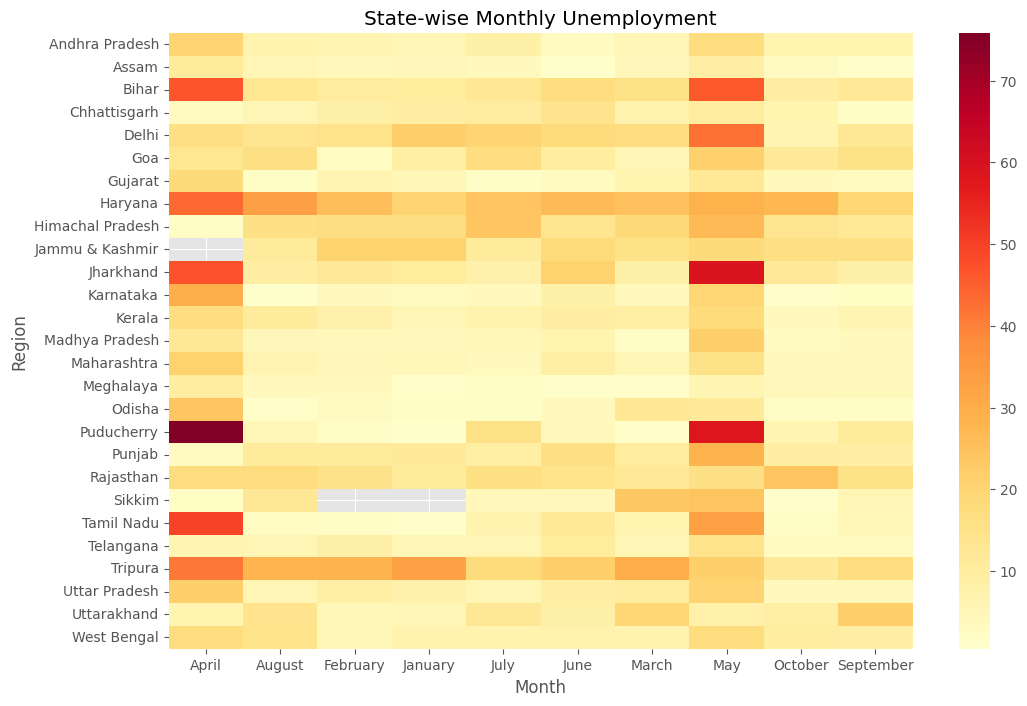

In [93]:
pivot = df.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Month'
)

plt.figure(figsize=(12,8))

sns.heatmap(pivot, cmap='YlOrRd')

plt.title("State-wise Monthly Unemployment")

plt.show()

In [94]:
df.nlargest(
    10,
    'Estimated Unemployment Rate (%)'
)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude,Month,Year,Covid
172,Puducherry,2020-04-30,M,75.85,117542,39.30,South,11.9416,79.8083,April,2020,During Covid
103,Jharkhand,2020-05-31,M,59.23,4145385,37.92,East,23.6102,85.2799,May,2020,During Covid
173,Puducherry,2020-05-31,M,58.19,172308,33.19,South,11.9416,79.8083,May,2020,During Covid
210,Tamil Nadu,2020-04-30,M,49.83,9719167,29.63,South,11.1271,78.6569,April,2020,During Covid
102,Jharkhand,2020-04-30,M,47.09,5335262,37.69,East,23.6102,85.2799,April,2020,During Covid
23,Bihar,2020-04-30,M,46.64,16046236,38.17,East,25.0961,85.3131,April,2020,During Covid
24,Bihar,2020-05-31,M,45.96,16280203,38.16,East,25.0961,85.3131,May,2020,During Covid
73,Haryana,2020-04-30,M,43.22,5647630,44.38,North,29.0588,76.0856,April,2020,During Covid
44,Delhi,2020-05-31,M,42.27,2632404,28.91,North,28.7041,77.1025,May,2020,During Covid
230,Tripura,2020-04-30,M,41.23,971514,51.16,Northeast,23.9408,91.9882,April,2020,During Covid


In [95]:
df.nsmallest(
    10,
    'Estimated Unemployment Rate (%)'
)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude,Month,Year,Covid
116,Karnataka,2020-08-31,M,0.50,24094289,43.13,South,15.3173,75.7139,August,2020,During Covid
169,Puducherry,2020-01-31,M,0.58,457950,37.46,South,11.9416,79.8083,January,2020,Before Covid
15,Assam,2020-06-30,M,0.60,9095944,35.07,Northeast,26.2006,92.9376,June,2020,During Covid
206,Sikkim,2020-10-31,M,0.88,242068,42.13,Northeast,27.5330,88.5122,October,2020,During Covid
154,Meghalaya,2020-06-30,M,1.15,1350794,58.31,Northeast,25.4670,91.3662,June,2020,During Covid
18,Assam,2020-09-30,M,1.19,14107641,54.38,Northeast,26.2006,92.9376,September,2020,During Covid
171,Puducherry,2020-03-31,M,1.20,421028,34.49,South,11.9416,79.8083,March,2020,During Covid
166,Odisha,2020-08-31,M,1.42,14154039,39.96,East,20.9517,85.0985,August,2020,During Covid
207,Tamil Nadu,2020-01-31,M,1.57,26881641,41.96,South,11.1271,78.6569,January,2020,Before Covid
118,Karnataka,2020-10-31,M,1.58,22356390,40.30,South,15.3173,75.7139,October,2020,During Covid


In [96]:
df['Estimated Unemployment Rate (%)'].mean()

np.float64(12.236928838951311)

In [97]:
df.groupby("Region")[
'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False)

,Estimated Unemployment Rate (%)
Region,
Haryana,27.477000
Tripura,25.055000
Jharkhand,19.539000
Bihar,19.471000
Delhi,18.414000
Puducherry,17.942000
Jammu & Kashmir,16.477778
Himachal Pradesh,16.065000
Rajasthan,15.868000


In [98]:
df.groupby("Covid")[
'Estimated Unemployment Rate (%)'
].mean()

,Estimated Unemployment Rate (%)
Covid,
Before Covid,9.231346
During Covid,12.963860


In [99]:
df.groupby("Month")[
'Estimated Unemployment Rate (%)'
].mean().sort_values()

,Estimated Unemployment Rate (%)
Month,
October,8.026296
September,8.705926
January,9.196538
February,9.266154
July,9.834444
August,10.313333
March,10.782593
June,10.911111
April,22.236154


# **Insights**
**Insight 1**

Average unemployment increased significantly during Covid-19.

**Insight 2**

Some states consistently had higher unemployment than others.

**Insight 3**

Lockdowns caused a sudden increase in unemployment.

**Insight 4**

Monthly unemployment showed seasonal fluctuations.

**Insight 5**

Recovery started after restrictions were eased.